<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion1_Prog_DS/blob/Chris/Evaluaci%C3%B3n_1_Prog_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import geopandas as gpd
from google.colab import drive
from shapely.geometry import Point

In [80]:
# Montar Google Drive
drive.mount('/content/drive')

# ============================================
# 1. Cargar sismos
# ============================================
df = pd.read_csv(
    '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_1/Raw/archive.zip',
    compression='zip'
)

print(f"Total de sismos antes de filtrar: {len(df):,}")
#print(f"Columnas: {df.columns.tolist()}")
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de sismos antes de filtrar: 1,054,683


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,cent19000105190000000,1900-01-05 19:00:00+00:00,1900,1,5,19,-3.0,102.0,NaN,7.0,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T00:16:56.005Z,reviewed
1,cent19000111090700000,1900-01-11 09:07:00+00:00,1900,1,11,9,-5.0,148.0,NaN,7.0,...,0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T22:55:15.621Z,reviewed
2,cent19000120063300000,1900-01-20 06:33:00+00:00,1900,1,20,6,20.0,-105.0,NaN,7.3,...,0,Great (7-8),NaN,NaN,NaN,NaN,NaN,cent,2025-04-19T23:36:34.400Z,reviewed


In [81]:
# ============================================
# 2. Cargar polígonos de Chile (tierra y mar)
# ============================================
print("\nCargando polígonos...")

# Tierra: Regiones de Chile
tierra = gpd.read_file(
    '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_1/Raw/REGIONES_v1.shp'
)

# Mar: ZEE de Chile (desde el XML)
mar = gpd.read_file(
    '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_1/Raw/eez.xml'
)

# ============================================
# CORRECCIÓN: Asignar CRS si no tiene
# ============================================
if tierra.crs is None:
    print("Asignando CRS a REGIONES (EPSG:4326)...")
    tierra = tierra.set_crs("EPSG:4326")

if mar.crs is None:
    print("Asignando CRS a ZEE (EPSG:4326)...")
    mar = mar.set_crs("EPSG:4326")

# Asegurar mismo sistema de coordenadas (WGS84 = EPSG:4326)
tierra = tierra.to_crs("EPSG:4326")
mar = mar.to_crs("EPSG:4326")

print(f"CRS de tierra: {tierra.crs}")
print(f"CRS de mar: {mar.crs}")

# Unir tierra + mar en un solo polígono
chile_total = pd.concat([tierra, mar], ignore_index=True)
chile_total = gpd.GeoDataFrame(chile_total, geometry='geometry', crs="EPSG:4326")
chile_total = chile_total.dissolve()  # Fusiona todo en un solo polígono

print("Polígonos cargados y unificados correctamente")



Cargando polígonos...
Asignando CRS a REGIONES (EPSG:4326)...
Asignando CRS a ZEE (EPSG:4326)...
CRS de tierra: EPSG:4326
CRS de mar: EPSG:4326
Polígonos cargados y unificados correctamente


In [82]:
# ============================================
# 3. Convertir sismos a GeoDataFrame
# ============================================
print("\nCreando geometría de puntos...")

sismos_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)

print(f"{len(sismos_gdf):,} puntos creados")


Creando geometría de puntos...
1,054,683 puntos creados


In [83]:
# ============================================
# 4. Filtrar sismos dentro de Chile
# ============================================
print("\nFiltrando sismos dentro de Chile...")

# Usamos intersects() en lugar de within() para incluir bordes
sismos_chile = sismos_gdf[sismos_gdf.intersects(chile_total.geometry.iloc[0])]

print(f"\n{'='*50}")
print(f"RESULTADOS DEL FILTRADO:")
print(f" Sismos TOTALES: {len(df):,}")
print(f" Sismos en CHILE: {len(sismos_chile):,}")
print(f" Sismos FUERA: {len(df) - len(sismos_chile):,}")
print(f" Porcentaje en Chile: {(len(sismos_chile)/len(df))*100:.2f}%")
print(f"{'='*50}")


Filtrando sismos dentro de Chile...

RESULTADOS DEL FILTRADO:
 Sismos TOTALES: 1,054,683
 Sismos en CHILE: 39,616
 Sismos FUERA: 1,015,067
 Porcentaje en Chile: 3.76%


In [84]:
##EXPORTACION DEL DATAFRAME A PROCESSED
import os

ruta_output = "/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_1/Processed/sismos_chile.csv"
sismos_chile.to_csv(ruta_output, index=False)

print(f"Archivo CSV guardado en: {ruta_output}")

Archivo CSV guardado en: /content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_1/Processed/sismos_chile.csv


In [112]:
sismos_procesado = sismos_chile.copy()

In [113]:
## ANALISIS EXPLORATORIO DE DATOS

#Nulos
print(sismos_procesado.isnull().sum())

# Valores únicos en la columna 'type'
print("Valores únicos en 'type':")
print(sismos_procesado['type'].unique())
print(f"Cantidad de valores únicos: {sismos_procesado['type'].nunique()}\n")

# Valores únicos en la columna 'tsunami'
print("Valores únicos en 'tsunami':")
print(sismos_procesado['tsunami'].unique())
print(f"Cantidad de valores únicos: {sismos_procesado['tsunami'].nunique()}")

## DADO QUE LAS COLUMNAS TYPE Y TSUNAMI NO TIENEN VALORES DISTINTOS NO NOS SIRVEN PARA REALIZAR UN ESTUDIO ASI QUE LOS VAMOS A ELIMINAR

## nst, gap, dmin, rms: Son columnas con un alto porcentaje de valores nulos (por ejemplo, dmin tiene ~80% de nulos). Estas métricas son útiles para evaluar la
##  calidad de la localización del sismo desde el punto de vista instrumental, pero para nuestro objetivo no son relevantes. Además, imputar valores tan
##  faltantes introduciría ruido innecesario.

## net, updated y status: net indica la red sísmica que reportó el evento (no aporta a nuestro modelo), updated es una marca de tiempo de la última actualización del registro,
##    no un atributo físico del sismo y finalmente status Indica si el evento fue revisado automática o manualmente lo cual no aporta a nuestro estudio.

## geometry: Es la columna de geometría del GeoDataFrame. Como nuestro análisis posterior no requiere operaciones espaciales (o porque ya extrajimos latitud/longitud),
##    la eliminamos para reducir memoria y simplificar el DataFrame. Si necesitamos mapas, podemos reconstruirla después.

## TODAS LAS COLUMNAS AQUI EVALUADAS SON CANDIDATAS A SER ELIMINADAS DE LA MUESTRA YA QUE NO NOS SIRVEN PARA NUESTRO ESTUDIO, ESTO NOS PERMITIRÁ DEJAR EL DATASET MAS LIMPIO
## ADEMAS SE SUMAN A ESTA LISTA LAS COLUMNAS time, year, month, day of the year y hour, ya que estas seran agrupadas en 2 unicas columnas de fecha y hora



id                    0
time                  0
year                  0
month                 0
day_of_year           0
hour                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
place                 0
type                  0
tsunami               0
mag_category          0
depth_category        0
nst               18872
gap               17646
dmin              31627
rms               18776
net                   0
updated               0
status                0
geometry              0
dtype: int64
Valores únicos en 'type':
['earthquake']
Cantidad de valores únicos: 1

Valores únicos en 'tsunami':
[0]
Cantidad de valores únicos: 1


In [114]:
## INICIO DEL PROCEDIMIENTO

sismos_procesado['fecha'] = pd.to_datetime(
    sismos_procesado['year'].astype(str) + '-' + sismos_procesado['day_of_year'].astype(str),
    format='%Y-%j')
sismos_procesado['hora'] = sismos_procesado['hour']

## Mascara de columnas para eliminar
columnas_a_eliminar = [
    'time', 'year', 'month', 'day_of_year', 'hour',   # originales de tiempo
    'nst', 'gap', 'dmin', 'rms', 'net', 'updated',    # nulos y metadata
    'status', 'geometry', 'type', 'tsunami'           # otras que no sirven para el estudio
]

## Aqui verificamos que las columnas existen antes de eliminar
existentes = [col for col in columnas_a_eliminar if col in sismos_procesado.columns]
sismos_procesado.drop(columns=existentes, inplace=True)

sismos_procesado.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 39616 entries, 83 to 1054663
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              39616 non-null  object        
 1   latitude        39616 non-null  float64       
 2   longitude       39616 non-null  float64       
 3   depth           39616 non-null  float64       
 4   mag             39616 non-null  float64       
 5   magType         39616 non-null  object        
 6   place           39616 non-null  object        
 7   mag_category    39616 non-null  object        
 8   depth_category  39616 non-null  object        
 9   fecha           39616 non-null  datetime64[ns]
 10  hora            39616 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 3.6+ MB


In [115]:
# Identificar outliers
Q1 = sismos_procesado['mag'].quantile(0.25)
Q3 = sismos_procesado['mag'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_mag = sismos_procesado[(sismos_procesado['mag'] < limite_inferior) |
                                 (sismos_procesado['mag'] > limite_superior)]
print(f"Magnitudes fuera de rango IQR: {len(outliers_mag)} eventos")
print("Estos corresponden a sismos de magnitud > ~6.5, que son los más relevantes para tsunamis. Por lo tanto, se conservan.")

Magnitudes fuera de rango IQR: 525 eventos
Estos corresponden a sismos de magnitud > ~6.5, que son los más relevantes para tsunamis. Por lo tanto, se conservan.


## A partir de el analisis de los outliers tomamos las siguientes decisiones

Decisión 1: Preservación de valores extremos (outliers)

En el proceso de limpieza, se identificaron valores atípicos en columnas como depth (profundidad) y mag (magnitud). Por ejemplo, profundidades negativas (errores instrumentales) o superiores a 600 km, y magnitudes mayores a 8.5. La práctica habitual en ciencia de datos sería recortar o eliminar estos registros. Sin embargo, en el contexto del estudio de sismicidad y riesgo de tsunamis, los valores extremos son los más relevantes desde el punto de vista científico.
Razones:
- Los terremotos de gran magnitud (Mw > 7.5) son poco frecuentes pero concentran la mayor parte del potencial destructivo y de generación de tsunamis. Eliminarlos como outliers sesgaría completamente el análisis, eliminando los eventos más importantes para la predicción de catástrofes.
- Profundidades anómalas (muy someras o muy profundas) permiten estudiar la correlación entre profundidad y generación de tsunamis. Por ejemplo, sismos superficiales (< 30 km) con alta magnitud son los que más tsunamis generan; sismos de subducción profunda (> 300 km) raramente generan tsunamis, pero su inclusión ayuda a delimitar umbrales.
- En lugar de eliminar outliers, se opta por mantener todos los registros originales y, en etapas posteriores (si se requiere modelado), se aplicarán técnicas robustas como RobustScaler (que usa mediana y rango intercuartil) o modelos basados en árboles que no son sensibles a valores extremos.

Por lo tanto, no se realiza ningún filtro por outliers en profundidad ni magnitud, preservando la integridad del fenómeno natural.

Decisión 2: Mantener la magnitud en su escala original sin estandarizar ni codificar

El dataset incluye una columna mag (valor numérico de magnitud) y una columna magType que indica la escala utilizada: ms (ondas superficiales), mw (magnitud momento), mb (ondas de cuerpo), ml (magnitud local), md (duración), mwb, mwc, mww, mwr (variantes de magnitud momento), y m (genérica). Cada una de estas escalas mide aspectos distintos del tamaño del sismo y no son linealmente equivalentes ni directamente comparables.

Razones para no aplicar técnicas de estandarización o codificación sobre la magnitud:

- Estandarizar (por ejemplo, con StandardScaler) implicaría restar la media y dividir por la desviación estándar de todos los valores de mag, independientemente de su magType. Esto mezcla escalas heterogéneas y produce una variable artificial sin interpretación física. Un sismo de mb=6.0 no es equivalente a uno de mw=6.0; la magnitud momento es más precisa y generalmente más alta para grandes terremotos.

- Estrategia adoptada: Se decide no transformar la columna mag numéricamente (no se escala, no se normaliza). En cambio, se conserva mag en su valor original y se utiliza magType como una variable categórica para análisis segmentados. Por ejemplo, se pueden generar visualizaciones separadas por tipo de magnitud, o filtrar solo eventos con magType='mw' (la más confiable) para ciertos modelos. Cualquier intento de estandarización global sería inapropiado y científicamente incorrecto.

Esta decisión mantiene la trazabilidad y el significado físico de los datos, evitando artefactos estadísticos sin respaldo geofísico.

In [ ]:
#mapa de calor en mapa global
import folium
from folium.plugins import HeatMap

# Asegurarte de que no haya nulos en lat/lon
sismos_procesado = sismos_procesado.dropna(subset=['latitude', 'longitude'])

# Crear mapa centrado en Chile
mapa_chile = folium.Map(
    location=[-35.5, -71.0],
    zoom_start=4,
    tiles='CartoDB positron'
)

# Extraer coordenadas para el heatmap
heat_data = sismos_procesado[['latitude', 'longitude']].values.tolist()

# Agregar mapa de calor
HeatMap(
    heat_data,
    radius=8,
    blur=6,
    max_zoom=10
).add_to(mapa_chile)

# Mostrar mapa
mapa_chile

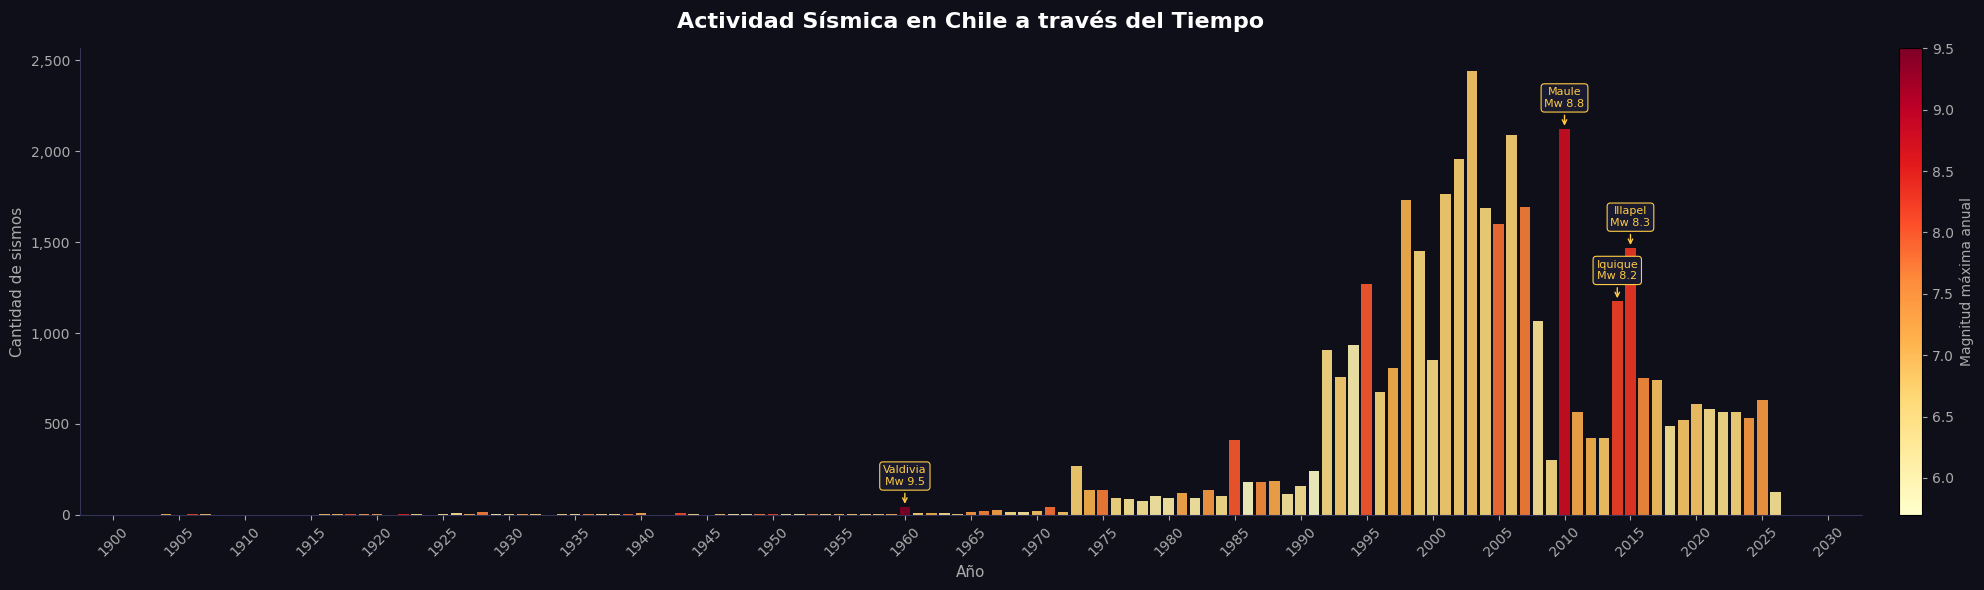

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
#grafico de barras por año
sismos_por_anio = (sismos_procesado
                   .groupby(sismos_procesado['fecha'].dt.year)
                   .agg(cantidad=('mag', 'count'),
                        mag_max=('mag', 'max'))
                   .reset_index()
                   .rename(columns={'fecha': 'year'})  # <-- clave: renombrar a 'year'
                  )

norm = plt.Normalize(sismos_por_anio['mag_max'].min(), sismos_por_anio['mag_max'].max())
cmap = plt.cm.YlOrRd

fig, ax = plt.subplots(figsize=(20, 6), facecolor='#0f0f1a')
ax.set_facecolor('#0f0f1a')
ax.tick_params(colors='#aaaaaa')
ax.spines['bottom'].set_color('#333355')
ax.spines['left'].set_color('#333355')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

colors = [cmap(norm(v)) for v in sismos_por_anio['mag_max']]
ax.bar(sismos_por_anio['year'], sismos_por_anio['cantidad'],
       color=colors, width=0.8, alpha=0.9)

ax.set_ylabel('Cantidad de sismos', color='#aaaaaa', fontsize=11)
ax.set_xlabel('Año', color='#aaaaaa', fontsize=11)
ax.set_title('Actividad Sísmica en Chile a través del Tiempo',
             color='white', fontsize=16, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.tick_params(axis='x', rotation=45)

eventos = {1960: 'Valdivia\nMw 9.5', 2010: 'Maule\nMw 8.8', 2014: 'Iquique\nMw 8.2', 2015: 'Illapel\nMw 8.3'}
for anio, label in eventos.items():
    if anio in sismos_por_anio['year'].values:
        y_val = sismos_por_anio[sismos_por_anio['year'] == anio]['cantidad'].values[0]
        ax.annotate(label, xy=(anio, y_val),
                    xytext=(anio, y_val + 120),
                    color='#ffcc44', fontsize=8, ha='center',
                    arrowprops=dict(arrowstyle='->', color='#ffcc44', lw=1),
                    bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec='#ffcc44', lw=0.8))

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Magnitud máxima anual', color='#aaaaaa', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')

plt.tight_layout()
plt.show()

### Transformacion de datos

In [118]:
# Convertir magType a categoría
sismos_procesado['magType'] = sismos_procesado['magType'].astype('category')

# Convertir depth_category a string
sismos_procesado['depth_category'] = sismos_procesado['depth_category'].astype('string')

# Convertir mag_category a string
sismos_procesado['mag_category'] = sismos_procesado['mag_category'].astype('string')

# Verificar los cambios
print(sismos_procesado.dtypes)

## Convertir magType a category y depth_category junto con mag_category a string optimiza la memoria y el rendimiento del DataFrame.
## El tipo category almacena valores repetidos de forma eficiente, mientras que string mejora el manejo de texto y evita errores típicos
## del tipo object, logrando un código más rápido y profesional sin perder información.

id                        object
latitude                 float64
longitude                float64
depth                    float64
mag                      float64
magType                 category
place                     object
mag_category      string[python]
depth_category    string[python]
fecha             datetime64[ns]
hora                       int64
dtype: object


###Hasta el momento el dataframe se ve asi :

In [119]:
sismos_procesado.head()

,id,latitude,longitude,depth,mag,magType,place,mag_category,depth_category,fecha,hora
83,iscgemsup16957812,-29.262,-71.753,20.0,7.00,ms,"86 km NW of La Serena, Chile",Major (6-7),Shallow (0-70km),1904-03-19,6
109,iscgemsup610548593,-32.312,-73.706,10.0,6.72,mw,"210 km WNW of Valparaíso, Chile",Major (6-7),Shallow (0-70km),1904-12-11,17
260,iscgemsup16957911,-32.400,-71.400,35.0,8.20,mw,"The 1906 Valparaiso, Chile Earthquake",Massive (8+),Shallow (0-70km),1906-08-17,0
261,iscgemsup16957914,-39.228,-72.721,15.0,6.74,mw,"17 km NNW of Loncoche, Chile",Major (6-7),Shallow (0-70km),1906-08-19,9
266,iscgem16957917,-18.358,-70.092,60.0,6.91,mw,"25 km ENE of Arica, Chile",Major (6-7),Shallow (0-70km),1906-08-30,2


## Feature Engineering
A partir de fecha y hora se crearon las siguientes

Estación del año (verano, otoño, invierno, primavera) como variable categórica.

Hora del día segmentada: mañana (6-12), tarde (12-18), noche (18-0), madrugada (0-6).

In [120]:
# 1. Estación del año a partir de 'fecha'
def estacion(mes):
    if mes in [12, 1, 2]:
        return 'verano'
    elif mes in [3, 4, 5]:
        return 'otoño'
    elif mes in [6, 7, 8]:
        return 'invierno'
    else:
        return 'primavera'

sismos_procesado['estacion'] = sismos_procesado['fecha'].dt.month.apply(estacion)

# 2. Hora del día (categoría)
def periodo_hora(hora):
    if 6 <= hora < 12:
        return 'mañana'
    elif 12 <= hora < 18:
        return 'tarde'
    elif 18 <= hora < 24:
        return 'noche'
    else:
        return 'madrugada'

sismos_procesado['periodo'] = sismos_procesado['hora'].apply(periodo_hora)

In [121]:
sismos_procesado.head()

,id,latitude,longitude,depth,mag,magType,place,mag_category,depth_category,fecha,hora,estacion,periodo
83,iscgemsup16957812,-29.262,-71.753,20.0,7.00,ms,"86 km NW of La Serena, Chile",Major (6-7),Shallow (0-70km),1904-03-19,6,otoño,mañana
109,iscgemsup610548593,-32.312,-73.706,10.0,6.72,mw,"210 km WNW of Valparaíso, Chile",Major (6-7),Shallow (0-70km),1904-12-11,17,verano,tarde
260,iscgemsup16957911,-32.400,-71.400,35.0,8.20,mw,"The 1906 Valparaiso, Chile Earthquake",Massive (8+),Shallow (0-70km),1906-08-17,0,invierno,madrugada
261,iscgemsup16957914,-39.228,-72.721,15.0,6.74,mw,"17 km NNW of Loncoche, Chile",Major (6-7),Shallow (0-70km),1906-08-19,9,invierno,mañana
266,iscgem16957917,-18.358,-70.092,60.0,6.91,mw,"25 km ENE of Arica, Chile",Major (6-7),Shallow (0-70km),1906-08-30,2,invierno,madrugada


#Metodología de transformación
###Escalado de variables numéricas

Se escalan latitude, longitude, depth y hora utilizando StandardScaler (media 0, desviación 1). No se escala mag porque es potencial variable objetivo. La razon es por que modelos como SVM, k‑NN o redes neuronales son sensibles a la escala de las features; sin escalado, variables como depth (0–700 km) dominarían sobre hora (0–23). Se eligió StandardScaler sobre MinMaxScaler porque es menos sensible a outliers y es el estándar en la mayoría de pipelines.

###Codificación de variables categóricas
Se codifica magType mediante One‑Hot Encoding. Esta variable es nominal (10 categorías sin orden). No se usa Label Encoding porque introduciría un orden falso que sesgaría el modelo. One‑Hot crea columnas binarias independientes, respetando la naturaleza de la variable. No se codifican mag_category ni depth_category por ser redundantes con mag y depth.

In [122]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Selección de columnas
num_features = ['latitude', 'longitude', 'depth', 'hora']
cat_features = ['magType']

# Preprocesador
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), num_features),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# Ajustar y transformar (ejemplo con X)
X = sismos_procesado[num_features + cat_features]
X_transformed = preprocessor.fit_transform(X)

# Obtener nombres de columnas resultantes
feature_names = num_features + list(preprocessor.named_transformers_['onehot'].get_feature_names_out(cat_features))
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

In [102]:
X_transformed_df.head()

,latitude,longitude,depth,hora,magType_m,magType_mb,magType_md,magType_ml,magType_ms,magType_mw,magType_mwb,magType_mwc,magType_mwr,magType_mww
0,0.244897,-0.403978,-0.792000,-0.756460,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.292309,-1.774932,-1.037746,0.827925,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.307808,-0.156181,-0.423381,-1.620671,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-1.510444,-1.083488,-0.914873,-0.324355,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2.165451,0.762000,0.190984,-1.332601,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
